# Welltory COVID 19 and Wearables Data Exploration

## 1. Data Context and Research Background

This notebook explores the Welltory COVID 19 and Wearables dataset, focusing on data quality, patterns, cleaning, transformation, and feature engineering.

The dataset contains anonymized participant, wearable, heart rate, HRV, sleep, survey, blood pressure, and weather data. All available records were used, so no sampling was applied during the initial exploration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Data Loading

In [2]:
import os
folder = "hrv-covid19/data"
files = os.listdir(folder)
files


['scales_description.csv',
 'participants.csv',
 'wearables.csv',
 'blood_pressure.csv',
 'surveys.csv',
 'heart_rate.csv',
 'weather.csv',
 'hrv_measurements.csv',
 'sleep.csv']

In [3]:
data = {}
for file in files:
    data[file] = pd.read_csv(f"{folder}/{file}")

for file, df in data.items():
    print(file, df.shape)

scales_description.csv (148, 4)
participants.csv (185, 8)
wearables.csv (3098, 18)
blood_pressure.csv (721, 8)
surveys.csv (2259, 5)
heart_rate.csv (523783, 4)
weather.csv (1717, 7)
hrv_measurements.csv (3245, 22)
sleep.csv (425, 12)


## 3. Data Structure and Initial Quality Assessment

In [4]:
for file, df in data.items():
    print(f"\nFile: {file}")
    print(f"Shape: {df.shape}")
    print("\nData Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("_" * 50)


File: scales_description.csv
Shape: (148, 4)

Data Types:
Scale          object
Description    object
Value           int64
Meaning        object
dtype: object

Missing Values:
Scale          0
Description    0
Value          0
Meaning        0
dtype: int64
__________________________________________________

File: participants.csv
Shape: (185, 8)

Data Types:
user_code          object
gender             object
age_range          object
city               object
country            object
height            float64
weight            float64
symptoms_onset     object
dtype: object

Missing Values:
user_code          0
gender             0
age_range          0
city              12
country            6
height             2
weight             0
symptoms_onset    38
dtype: int64
__________________________________________________

File: wearables.csv
Shape: (3098, 18)

Data Types:
user_code                           object
day                                 object
resting_pulse               

## 4. Descriptive Statistics

In [5]:
for file, df in data.items():
    print(f"\nFile: {file}")
    display(df.describe(include="all").T)


File: scales_description.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Scale,148,74,S_HEART,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,148,72,Symptom intensity: Coughing,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Value,148.0,NaN,NaN,NaN,2.331081,1.655288,1.0,1.0,1.5,3.25,6.0
Meaning,148,99,Extremely severe,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN



File: participants.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_code,185,185,007b8190cf,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,185,2,f,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_range,185,6,35-44,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,173,116,Moscow,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,179,25,Russia,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,183.0,NaN,NaN,NaN,169.976393,12.400103,132.08,163.5,168.0,174.5,250.0
weight,185.0,NaN,NaN,NaN,77.927757,19.552541,43.5,63.5,74.344,90.537,154.221
symptoms_onset,147,74,5/6/2020,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN



File: wearables.csv


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_code,1717,104,295ed96279,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,1717,169,2020-05-06,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_temperature_C,1717.0,NaN,NaN,NaN,11.839221,7.769565,-13.15,6.4722,11.2722,16.6639,44.0722
atmospheric_pressure,1717.0,NaN,NaN,NaN,1014.111639,8.356792,984.3,1009.0,1014.1,1019.5667,1047.75
precip_intensity,1717.0,NaN,NaN,NaN,0.003803,0.015348,0.0,0.0,0.0002,0.0017,0.2567
humidity,1717.0,NaN,NaN,NaN,66.376586,19.33967,3.0,54.0,68.0,81.0,100.0
clouds,1717.0,NaN,NaN,NaN,56.401734,35.048917,0.0,24.5,61.5,91.0,100.0



File: hrv_measurements.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_code,3245,185,a62c11c164,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rr_code,3245,3245,10489a6aea,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
measurement_datetime,3245,3241,2020-05-15 09:31:35,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_of_day,3245,4,morning,1467,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bpm,3245.0,NaN,NaN,NaN,73.257935,12.201088,44.0,65.0,72.0,81.0,125.0
meanrr,3245.0,NaN,NaN,NaN,839.600366,137.420367,477.73,742.49,829.1,925.933,1346.74
mxdmn,3245.0,NaN,NaN,NaN,0.184635,0.107456,0.03,0.11,0.16,0.22,0.79
sdnn,3245.0,NaN,NaN,NaN,52.489218,29.369506,9.515,32.585,46.919,64.406,206.631
rmssd,3245.0,NaN,NaN,NaN,52.814196,39.353213,6.34,28.985,42.869,62.485,310.8
pnn50,3245.0,NaN,NaN,NaN,20.615609,18.588156,0.0,6.06,16.16,29.29,91.92



File: sleep.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_code,425,10,6be5033971,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,425,154,2020-05-16,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_begin,425,424,2020-05-19 00:03:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_end,425,425,2019-12-31 08:45:22,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_duration,425.0,NaN,NaN,NaN,25699.731765,7773.80547,930.0,21857.0,26041.0,30600.0,47460.0
sleep_awake_duration,9.0,NaN,NaN,NaN,2733.333333,671.90029,1740.0,2460.0,2490.0,2790.0,4200.0
sleep_rem_duration,7.0,NaN,NaN,NaN,6518.571429,2081.613385,2820.0,5730.0,6240.0,8190.0,8730.0
sleep_light_duration,27.0,NaN,NaN,NaN,14514.740741,8078.12629,300.0,7995.0,17340.0,20340.0,23100.0
sleep_deep_duration,14.0,NaN,NaN,NaN,4280.285714,2089.766547,480.0,2797.5,4230.0,5550.0,7934.0
pulse_min,15.0,NaN,NaN,NaN,60.533333,12.844491,52.0,54.5,58.0,60.0,105.0


The datasets vary greatly in size and coverage, with heart rate containing the most observations. Several variables also show wide ranges that require further investigation.

## 5. Missing Values

In [6]:
for file, df in data.items():
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100

    missing_summary = pd.DataFrame({
        "Missing Count": missing,
        "Missing Percentage": missing_percent
    })

    if missing.sum() > 0:
        print(f"\nFile: {file}")
        display(missing_summary[missing_summary["Missing Count"] > 0])


File: participants.csv


,Missing Count,Missing Percentage
city,12,6.486486
country,6,3.243243
height,2,1.081081
symptoms_onset,38,20.540541



File: wearables.csv


,Missing Count,Missing Percentage
resting_pulse,1583,51.097482
pulse_average,1009,32.569400
pulse_min,1009,32.569400
pulse_max,1009,32.569400
average_spo2_value,3058,98.708844
body_temperature_avg,3033,97.901872
stand_hours_total,2567,82.859910
steps_count,1130,36.475145
distance,1229,39.670755
steps_speed,1680,54.228535



File: blood_pressure.csv


,Missing Count,Missing Percentage
functional_changes_index,422,58.52982
circulatory_efficiency,422,58.52982
kerdo_vegetation_index,438,60.74896
robinson_index,422,58.52982



File: hrv_measurements.csv


,Missing Count,Missing Percentage
how_sleep,1779,54.822804
tags,1044,32.172573



File: sleep.csv


,Missing Count,Missing Percentage
sleep_awake_duration,416,97.882353
sleep_rem_duration,418,98.352941
sleep_light_duration,398,93.647059
sleep_deep_duration,411,96.705882
pulse_min,410,96.470588
pulse_max,410,96.470588
pulse_average,410,96.470588


Missingness was highest in the wearable and sleep datasets.

## 6. Duplicate Analysis

In [7]:
for file, df in data.items():
    duplicates_rows = df.duplicated().sum()
    print(f"{file}: {duplicates_rows} duplicate rows")

scales_description.csv: 0 duplicate rows
participants.csv: 0 duplicate rows
wearables.csv: 0 duplicate rows
blood_pressure.csv: 0 duplicate rows
surveys.csv: 0 duplicate rows
heart_rate.csv: 0 duplicate rows
weather.csv: 0 duplicate rows
hrv_measurements.csv: 0 duplicate rows
sleep.csv: 0 duplicate rows


No exact duplicate rows were found, so no rows were removed.

## 7. Outlier Analysis

In [8]:
participants = data["participants.csv"]
heart_rate = data["heart_rate.csv"]
wearables = data["wearables.csv"]
hrv = data["hrv_measurements.csv"]

In [9]:
display(participants[["height", "weight"]].sort_values("height").head(10))
display(participants[["height", "weight"]].sort_values("height").tail(10))

,height,weight
65,132.08,67.903
171,149.86,78.471
16,152.00,69.173
48,152.40,88.677
21,154.00,67.000
84,154.94,65.771
86,154.94,49.124
178,154.94,130.300
177,154.94,47.673
121,156.00,73.000


,height,weight
160,188.00,117.000
116,189.00,89.500
112,190.00,102.000
175,193.00,90.000
136,193.00,65.998
83,203.00,70.534
49,248.92,114.713
102,250.00,82.146
8,NaN,75.977
37,NaN,69.100


In [10]:
display(participants[["height", "weight"]].sort_values("weight").head(10))
display(participants[["height", "weight"]].sort_values("weight").tail(10))

,height,weight
87,159.00,43.500
134,160.00,46.402
177,154.94,47.673
55,170.00,48.000
86,154.94,49.124
153,165.00,49.500
50,164.00,50.000
115,168.00,50.000
56,177.00,51.029
118,160.02,51.709


,height,weight
49,248.92,114.713
139,173.00,115.000
180,165.00,115.439
160,188.00,117.000
169,158.00,120.000
52,162.00,123.967
178,154.94,130.300
24,159.00,132.900
109,165.10,133.810
137,170.18,154.221


In [11]:
display(heart_rate.sort_values("heart_rate").head(10))
display(heart_rate.sort_values("heart_rate").tail(10))

,user_code,datetime,heart_rate,is_resting
83727,35c7355282,2020-02-18 19:24:10,10,0
61268,35c7355282,2020-02-12 20:16:26,11,0
60974,35c7355282,2020-02-12 20:10:42,12,0
83826,35c7355282,2020-02-18 19:26:51,12,0
60981,35c7355282,2020-02-12 20:10:49,12,0
60980,35c7355282,2020-02-12 20:10:48,12,0
60979,35c7355282,2020-02-12 20:10:47,12,0
60978,35c7355282,2020-02-12 20:10:46,12,0
60977,35c7355282,2020-02-12 20:10:45,12,0
60976,35c7355282,2020-02-12 20:10:44,12,0


,user_code,datetime,heart_rate,is_resting
83738,35c7355282,2020-02-18 19:24:22,225,0
83732,35c7355282,2020-02-18 19:24:15,225,0
83733,35c7355282,2020-02-18 19:24:16,225,0
83734,35c7355282,2020-02-18 19:24:18,225,0
83735,35c7355282,2020-02-18 19:24:19,225,0
83736,35c7355282,2020-02-18 19:24:20,225,0
83737,35c7355282,2020-02-18 19:24:21,225,0
83729,35c7355282,2020-02-18 19:24:12,225,0
74408,35c7355282,2020-02-16 19:00:20,232,0
74409,35c7355282,2020-02-16 19:00:21,232,0


In [12]:
print("Heart rate below 40:")
display(heart_rate[heart_rate["heart_rate"] < 40])

print("Heart rate above 200:")
display(heart_rate[heart_rate["heart_rate"] > 200])

Heart rate below 40:


,user_code,datetime,heart_rate,is_resting
9953,35c7355282,2020-01-03 16:34:34,30,0
9954,35c7355282,2020-01-03 16:34:38,37,0
9959,35c7355282,2020-01-03 16:44:21,36,0
9962,35c7355282,2020-01-03 16:46:42,34,0
9968,35c7355282,2020-01-03 16:54:05,33,0
...,...,...,...,...
297860,6be5033971,2020-06-16 19:09:57,37,0
297863,6be5033971,2020-06-16 19:13:07,32,0
297864,6be5033971,2020-06-16 19:13:37,31,0
297866,6be5033971,2020-06-16 19:15:08,34,0


Heart rate above 200:


,user_code,datetime,heart_rate,is_resting
31605,35c7355282,2020-02-02 17:31:16,209,0
31607,35c7355282,2020-02-02 17:31:18,209,0
31608,35c7355282,2020-02-02 17:31:19,209,0
31609,35c7355282,2020-02-02 17:31:20,209,0
31610,35c7355282,2020-02-02 17:31:21,209,0
...,...,...,...,...
85390,35c7355282,2020-02-18 19:54:00,207,0
85391,35c7355282,2020-02-18 19:54:01,207,0
85392,35c7355282,2020-02-18 19:54:02,207,0
190877,4985083f4d,2020-05-15 05:51:46,210,0


In [13]:
display(
    wearables.dropna(subset=["pulse_min"])
    .sort_values("pulse_min")
    .head(10)
)

display(
    wearables.dropna(subset=["pulse_max"])
    .sort_values("pulse_max")
    .tail(10)
)

,user_code,day,resting_pulse,pulse_average,pulse_min,pulse_max,average_spo2_value,body_temperature_avg,stand_hours_total,steps_count,distance,steps_speed,total_number_of_flights_climbed,active_calories_burned,basal_calories_burned,total_calories_burned,average_headphone_exposure,average_environment_exposure
678,35c7355282,2020-02-18,49.0,122.0,10.0,225.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2741.0,2741.0,NaN,NaN
664,35c7355282,2020-02-02,57.0,117.0,16.0,211.0,NaN,NaN,NaN,9701.0,NaN,NaN,NaN,451.0,2741.0,3192.0,81.02,67.88
666,35c7355282,2020-02-04,44.0,106.0,18.0,216.0,NaN,NaN,NaN,73.0,NaN,2.70,NaN,NaN,2741.0,2741.0,NaN,NaN
652,35c7355282,2020-01-20,44.0,104.0,28.0,183.0,NaN,NaN,NaN,914.0,NaN,NaN,NaN,18.0,2741.0,2759.0,NaN,NaN
640,35c7355282,2020-01-05,40.0,61.0,28.0,171.0,NaN,NaN,NaN,14806.0,NaN,NaN,NaN,443.0,2741.0,3184.0,NaN,NaN
1355,6be5033971,2020-03-25,48.0,76.0,29.0,131.0,NaN,36.3,NaN,5784.0,3847.0,47.03,11.0,NaN,1761.0,1761.0,NaN,51.06
641,35c7355282,2020-01-06,41.0,68.0,30.0,181.0,NaN,NaN,NaN,19.0,NaN,NaN,NaN,1.0,2741.0,2742.0,NaN,NaN
1415,6be5033971,2020-05-25,47.0,66.0,30.0,104.0,0.96,36.3,12.0,2828.0,2009.0,18.16,NaN,7.0,1799.0,1806.0,NaN,56.13
638,35c7355282,2020-01-03,44.0,104.0,30.0,160.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2741.0,2741.0,NaN,NaN
1432,6be5033971,2020-06-16,42.0,91.0,31.0,137.0,NaN,NaN,17.0,16009.0,10863.0,0.89,34.0,84.0,1799.0,1883.0,NaN,56.67


,user_code,day,resting_pulse,pulse_average,pulse_min,pulse_max,average_spo2_value,body_temperature_avg,stand_hours_total,steps_count,distance,steps_speed,total_number_of_flights_climbed,active_calories_burned,basal_calories_burned,total_calories_burned,average_headphone_exposure,average_environment_exposure
2407,cdf7848d2b,2020-04-20,49.0,128.0,46.0,190.0,NaN,NaN,NaN,NaN,2826.0,NaN,NaN,5.0,2477.0,2482.0,NaN,NaN
2431,cdf7848d2b,2020-05-15,51.0,142.0,47.0,190.0,NaN,NaN,6.0,6115.0,4861.0,30.58,2.0,138.0,2467.0,2605.0,NaN,NaN
2101,b523b4512b,2020-05-22,64.0,86.0,60.0,193.0,NaN,NaN,9.0,4740.0,3019.0,12.46,NaN,247.0,2316.0,2563.0,NaN,NaN
2399,cdf7848d2b,2020-04-12,51.0,141.0,55.0,196.0,NaN,NaN,NaN,NaN,4683.0,NaN,NaN,NaN,2477.0,2477.0,NaN,NaN
1358,6be5033971,2020-03-28,50.0,98.0,31.0,197.0,0.99,36.8,NaN,4457.0,3567.0,28.93,12.0,7.0,1761.0,1768.0,NaN,NaN
1365,6be5033971,2020-04-04,46.0,70.0,45.0,203.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1802.0,1802.0,NaN,44.73
972,4985083f4d,2020-05-15,53.0,83.0,53.0,210.0,NaN,NaN,14.0,NaN,NaN,NaN,NaN,53.0,1817.0,1870.0,39.89,NaN
664,35c7355282,2020-02-02,57.0,117.0,16.0,211.0,NaN,NaN,NaN,9701.0,NaN,NaN,NaN,451.0,2741.0,3192.0,81.02,67.88
666,35c7355282,2020-02-04,44.0,106.0,18.0,216.0,NaN,NaN,NaN,73.0,NaN,2.70,NaN,NaN,2741.0,2741.0,NaN,NaN
678,35c7355282,2020-02-18,49.0,122.0,10.0,225.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2741.0,2741.0,NaN,NaN


In [14]:
for column in ["bpm", "sdnn", "rmssd"]:
    print(f"\nLowest {column}:")
    display(
        hrv[["user_code", "measurement_datetime", column]]
        .sort_values(column)
        .head(10)
    )

    print(f"Highest {column}:")
    display(
        hrv[["user_code", "measurement_datetime", column]]
        .sort_values(column)
        .tail(10)
    )


Lowest bpm:


,user_code,measurement_datetime,bpm
963,4da9d39406,2020-05-15 03:26:30,44
737,3769e88689,2020-06-18 21:53:40,45
736,3769e88689,2020-06-18 21:08:21,45
289,1fa680ad84,2020-05-23 00:38:09,46
705,3769e88689,2020-05-14 05:36:43,47
1246,6be5033971,2020-05-22 06:26:44,47
654,2bb535769b,2020-05-11 06:33:53,48
722,3769e88689,2020-05-25 19:32:11,49
591,295ed96279,2020-05-22 10:20:43,49
689,3769e88689,2020-04-27 06:51:27,49


Highest bpm:


,user_code,measurement_datetime,bpm
1076,56c1b0b382,2020-05-07 14:35:37,109
2493,c174f32d88,2020-02-06 21:53:15,110
2611,c174f32d88,2020-05-04 22:56:10,110
2552,c174f32d88,2020-03-08 22:16:27,110
2612,c174f32d88,2020-05-05 23:31:56,110
2468,c174f32d88,2020-01-30 20:13:24,111
2636,cdf7848d2b,2020-05-13 12:20:12,111
2521,c174f32d88,2020-02-23 23:14:03,116
2582,c174f32d88,2020-04-01 23:38:28,117
2492,c174f32d88,2020-02-06 16:12:38,125



Lowest sdnn:


...

,user_code,measurement_datetime,sdnn
2882,f9edcb7056,2020-05-05 10:42:46,182.995
2938,f9edcb7056,2020-06-08 07:01:50,183.798
2926,f9edcb7056,2020-06-01 23:17:45,183.822
2899,f9edcb7056,2020-05-12 23:02:38,186.495
2868,f9edcb7056,2020-05-01 10:43:36,187.109
2863,f9edcb7056,2020-04-29 11:27:01,187.268
2859,f9edcb7056,2020-04-27 22:31:45,187.419
2912,f9edcb7056,2020-05-22 10:13:20,193.519
2823,ec5fda0a7a,2020-05-06 11:40:08,204.016
2342,af141758f3,2020-01-14 11:07:50,206.631



Lowest rmssd:


,user_code,measurement_datetime,rmssd
641,29d2a4bb3a,2020-04-20 19:54:02,6.340
2969,fcf3ea75b0,2020-01-07 14:15:39,6.996
61,01bad5a519,2020-05-07 18:16:40,7.561
570,295ed96279,2020-05-12 09:56:32,8.340
2379,b592b38671,2020-05-14 23:22:56,8.449
959,4d23664d6f,2020-04-24 21:59:32,9.407
281,1f2eb6aded,2020-06-05 21:50:29,9.670
822,425969dc69,2020-03-21 20:24:03,9.789
1711,a1c2e6b2eb,2020-04-28 18:34:16,9.928
865,42a99d8248,2020-05-06 10:48:43,10.057


Highest rmssd:


,user_code,measurement_datetime,rmssd
2873,f9edcb7056,2020-05-03 12:16:29,254.591
2933,f9edcb7056,2020-06-05 06:39:48,256.793
2902,f9edcb7056,2020-05-15 09:15:14,261.208
2926,f9edcb7056,2020-06-01 23:17:45,271.309
2886,f9edcb7056,2020-05-06 22:41:38,271.546
2882,f9edcb7056,2020-05-05 10:42:46,271.810
2908,f9edcb7056,2020-05-20 10:17:55,273.589
2899,f9edcb7056,2020-05-12 23:02:38,275.786
2912,f9edcb7056,2020-05-22 10:13:20,277.096
2823,ec5fda0a7a,2020-05-06 11:40:08,310.800


Potential outliers were reviewed. Questionable heights were cleaned, while heart rate and HRV extremes were retained.

## 8. Data Cleaning and Transformations

In [15]:
participants = data["participants.csv"]
participants_clean = participants.copy()

In [16]:
participants_clean[participants_clean["height"] > 220]
participants_clean.loc[
    participants_clean["height"] > 220,
    "height"
] = np.nan

participants_clean["height"].max()

203.0

Two unusually high height values were replaced with missing values while keeping the participant records.

In [17]:
participants_clean["symptoms_onset"] = pd.to_datetime(
    participants_clean["symptoms_onset"],
    errors="coerce"
)

participants_clean.dtypes

user_code                 object
gender                    object
age_range                 object
city                      object
country                   object
height                   float64
weight                   float64
symptoms_onset    datetime64[ns]
dtype: object

The symptoms onset column was converted to datetime format for easier date based analysis.

In [18]:
participants_clean.isnull().sum()

user_code          0
gender             0
age_range          0
city              12
country            6
height             4
weight             0
symptoms_onset    38
dtype: int64

Missing participant values were retained because there was not enough information to accurately impute them.

In [19]:
wearables = data["wearables.csv"]
wearables_clean = wearables.copy()
missing_percent = wearables_clean.isnull().mean() * 100
missing_percent[missing_percent > 90]

average_spo2_value              98.708844
body_temperature_avg            97.901872
average_headphone_exposure      92.575855
average_environment_exposure    95.190445
dtype: float64

In [20]:
wearables_clean = wearables_clean.drop(columns=[
    "average_spo2_value",
    "body_temperature_avg",
    "average_headphone_exposure",
    "average_environment_exposure"
])

Four wearable features were removed because more than 90% of their values were missing.

In [21]:
wearables_clean["day"] = pd.to_datetime(wearables_clean["day"])
wearables_clean.dtypes

user_code                                  object
day                                datetime64[ns]
resting_pulse                             float64
pulse_average                             float64
pulse_min                                 float64
pulse_max                                 float64
stand_hours_total                         float64
steps_count                               float64
distance                                  float64
steps_speed                               float64
total_number_of_flights_climbed           float64
active_calories_burned                    float64
basal_calories_burned                     float64
total_calories_burned                     float64
dtype: object

Remaining missing wearable values were retained because unavailable measurements should not be replaced with estimated values.

In [22]:
heart_rate = data["heart_rate.csv"]
heart_rate_clean = heart_rate.copy()

heart_rate_clean["datetime"] = pd.to_datetime(
    heart_rate_clean["datetime"]
)

heart_rate_clean.dtypes

user_code             object
datetime      datetime64[ns]
heart_rate             int64
is_resting             int64
dtype: object

In [23]:
hrv = data["hrv_measurements.csv"]
hrv_clean = hrv.copy()

hrv_clean["measurement_datetime"] = pd.to_datetime(
    hrv_clean["measurement_datetime"]
)

hrv_clean.dtypes

user_code                       object
rr_code                         object
measurement_datetime    datetime64[ns]
time_of_day                     object
bpm                              int64
meanrr                         float64
mxdmn                          float64
sdnn                           float64
rmssd                          float64
pnn50                          float64
mode                           float64
amo                            float64
lf                             float64
hf                             float64
vlf                            float64
lfhf                           float64
total_power                    float64
how_feel                         int64
how_mood                         int64
how_sleep                      float64
tags                            object
rr_data                         object
dtype: object

In [24]:
blood_pressure = data["blood_pressure.csv"]
blood_pressure_clean = blood_pressure.copy()

blood_pressure_clean["measurement_datetime"] = pd.to_datetime(
    blood_pressure_clean["measurement_datetime"]
)

blood_pressure_clean.dtypes

user_code                           object
measurement_datetime        datetime64[ns]
diastolic                            int64
systolic                             int64
functional_changes_index           float64
circulatory_efficiency             float64
kerdo_vegetation_index             float64
robinson_index                     float64
dtype: object

In [25]:
surveys = data["surveys.csv"]
surveys_clean = surveys.copy()

surveys_clean["created_at"] = pd.to_datetime(
    surveys_clean["created_at"]
)

surveys_clean.dtypes

user_code             object
scale                 object
created_at    datetime64[ns]
value                  int64
text                  object
dtype: object

In [26]:
weather = data["weather.csv"]
weather_clean = weather.copy()

weather_clean["day"] = pd.to_datetime(
    weather_clean["day"]
)

weather_clean.dtypes

user_code                       object
day                     datetime64[ns]
avg_temperature_C              float64
atmospheric_pressure           float64
precip_intensity               float64
humidity                       float64
clouds                         float64
dtype: object

In [27]:
sleep = data["sleep.csv"]
sleep_clean = sleep.copy()

missing_percent = sleep_clean.isnull().mean() * 100
missing_percent[missing_percent > 90]

sleep_awake_duration    97.882353
sleep_rem_duration      98.352941
sleep_light_duration    93.647059
sleep_deep_duration     96.705882
pulse_min               96.470588
pulse_max               96.470588
pulse_average           96.470588
dtype: float64

In [28]:
sleep_clean = sleep_clean.drop(columns=[
    "sleep_awake_duration",
    "sleep_rem_duration",
    "sleep_light_duration",
    "sleep_deep_duration",
    "pulse_min",
    "pulse_max",
    "pulse_average"
])

Seven sleep features with over 90% missing values were removed because there was not enough data to reliably impute them.

In [29]:
sleep_clean["day"] = pd.to_datetime(sleep_clean["day"])
sleep_clean["sleep_begin"] = pd.to_datetime(sleep_clean["sleep_begin"])
sleep_clean["sleep_end"] = pd.to_datetime(sleep_clean["sleep_end"])

sleep_clean.dtypes

user_code                 object
day               datetime64[ns]
sleep_begin       datetime64[ns]
sleep_end         datetime64[ns]
sleep_duration           float64
dtype: object

In [30]:
participants_clean.loc[
    participants_clean["symptoms_onset"].dt.year != 2020,
    "symptoms_onset"
] = pd.NaT

Symptom onset dates outside 2020 were treated as invalid and replaced with missing values.

## 9. Feature Engineering

A new feature was created to provide additional information from the existing variables.

In [31]:
wearables_clean = wearables_clean.merge(
    participants_clean[["user_code", "symptoms_onset"]],
    on="user_code",
    how="left"
)

wearables_clean["days_from_symptoms"] = (
    wearables_clean["day"] - wearables_clean["symptoms_onset"]
).dt.days

In [32]:
wearables_clean[
    ["user_code", "day", "symptoms_onset", "days_from_symptoms"]
].dropna().head(10)

,user_code,day,symptoms_onset,days_from_symptoms
1,01bad5a519,2020-02-12,2020-04-05,-53.0
2,01bad5a519,2020-02-13,2020-04-05,-52.0
3,01bad5a519,2020-02-15,2020-04-05,-50.0
4,01bad5a519,2020-02-16,2020-04-05,-49.0
5,01bad5a519,2020-02-17,2020-04-05,-48.0
6,01bad5a519,2020-02-18,2020-04-05,-47.0
7,01bad5a519,2020-02-19,2020-04-05,-46.0
8,01bad5a519,2020-02-20,2020-04-05,-45.0
9,01bad5a519,2020-02-22,2020-04-05,-43.0
10,01bad5a519,2020-02-23,2020-04-05,-42.0


A days from symptoms feature was created to show when wearable measurements occurred relative to symptom onset.


## 10. Visualizations and Variable Relationships

In [33]:
pulse_by_day = (
    wearables_clean[
        wearables_clean["days_from_symptoms"].between(-30, 30)
    ]
    .groupby("days_from_symptoms")["resting_pulse"]
    .mean()
)

In [34]:
plt.figure(figsize=(9, 5))

plt.plot(
    pulse_by_day.index,
    pulse_by_day.values,
    marker="o"
)

plt.axvline(0, linestyle="--")

plt.xlabel("Days From Symptom Onset")
plt.ylabel("Average Resting Pulse")
plt.title("Average Resting Pulse Around Symptom Onset")

plt.show()

<Figure size 900x500 with 1 Axes>

Average resting pulse appears to increase around symptom onset, although there is substantial variation before and after symptoms.

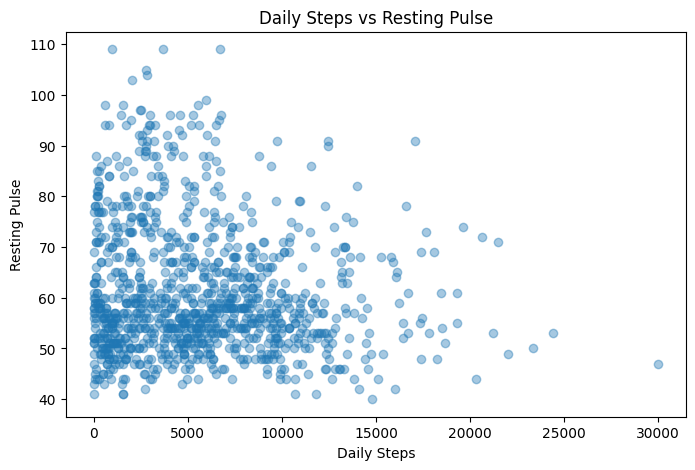

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(
    wearables_clean["steps_count"],
    wearables_clean["resting_pulse"],
    alpha=0.4
)

plt.xlabel("Daily Steps")
plt.ylabel("Resting Pulse")
plt.title("Daily Steps vs Resting Pulse")
plt.show()

Higher daily step counts appear to be associated with a slightly lower resting pulse, although there is considerable variation.

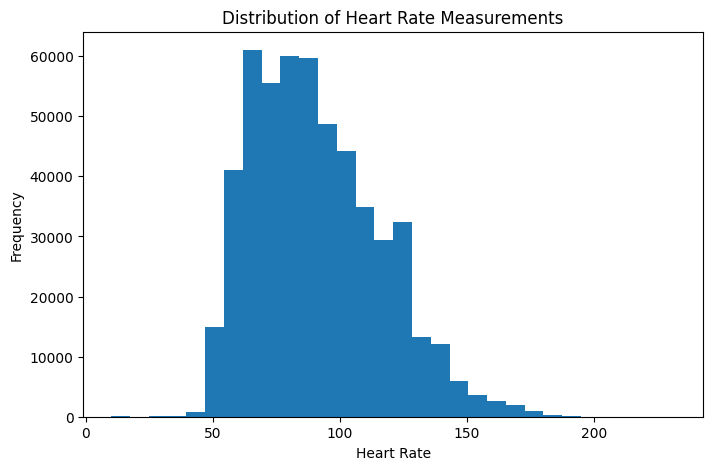

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(
    heart_rate_clean["heart_rate"],
    bins=30
)

plt.xlabel("Heart Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Heart Rate Measurements")
plt.show()

Most heart rate measurements are concentrated between about 50 and 120 bpm, with relatively few extreme values.

## 11. Data Quality Assessment

Profiling: Data types, statistics, missing values, duplicates, and outliers were examined.

Completeness: Highly missing wearable and sleep features were removed.

Accuracy: Questionable height and symptom dates were cleaned, while uncertain heart rate extremes were retained.

Consistency: Date columns were converted to datetime format.

Integrity: user_code connects participants across datasets.

Provenance: The data comes from the Welltory COVID 19 and Wearables dataset, with original data preserved.

In [37]:
for file, df in data.items():
    if "user_code" in df.columns and file != "participants.csv":
        unknown = (~df["user_code"].isin(participants["user_code"])).sum()
        print(f"{file}: {unknown} unknown user codes")

wearables.csv: 0 unknown user codes
blood_pressure.csv: 0 unknown user codes
surveys.csv: 0 unknown user codes
heart_rate.csv: 0 unknown user codes
weather.csv: 0 unknown user codes
hrv_measurements.csv: 0 unknown user codes
sleep.csv: 0 unknown user codes


All user codes in the measurement datasets match participants in the participant dataset, indicating consistent links across the data.